In [1]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

results = {}

def evaluate_model(name, model, X_val, y_val, classes):
    y_true = y_val.argmax(axis=1)
    y_pred = model.predict(X_val).argmax(axis=1)

    report = classification_report(y_true, y_pred, target_names=classes, digits=3, output_dict=True)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)

    results[name] = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "report": report
    }


In [2]:
from tensorflow.keras.models import load_model
import numpy as np, json

data = np.load("preprocessed_arrays.npz")
x_val_pad = data["X_val_pad"]
y_val_cat = data["y_val_cat"]

with open("label_encoder_classes.json", "r", encoding="utf-8") as f:
    classes = json.load(f)

lstm_model    = load_model("Models/lstm_model.keras")
bilstm_model  = load_model("Models/bilstm_model.keras")
stacked_model = load_model("Models/stacked_lstm_model.keras")
cnnlstm_model = load_model("Models/cnn_lstm_model.keras")

evaluate_model("LSTM",          lstm_model,    x_val_pad, y_val_cat, classes)
evaluate_model("BiLSTM",        bilstm_model,  x_val_pad, y_val_cat, classes)
evaluate_model("Stacked LSTM",  stacked_model, x_val_pad, y_val_cat, classes)
evaluate_model("CNN-LSTM",      cnnlstm_model, x_val_pad, y_val_cat, classes)


188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step


In [3]:
import pandas as pd

summary = pd.DataFrame({
    model: {"Accuracy": res["accuracy"], "Macro F1": res["macro_f1"]}
    for model, res in results.items()
}).T

print(summary)

              Accuracy  Macro F1
LSTM          0.769500  0.768915
BiLSTM        0.741000  0.740433
Stacked LSTM  0.758167  0.757481
CNN-LSTM      0.683500  0.685466


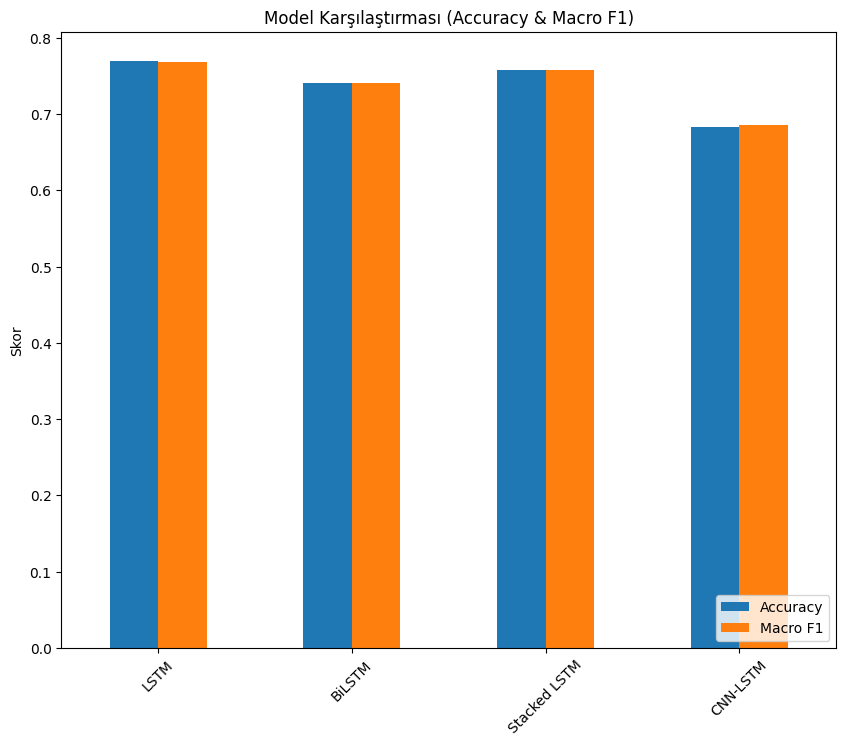

In [6]:
import matplotlib.pyplot as plt

summary.plot(kind="bar", figsize=(10,8))
plt.title("Model Karşılaştırması (Accuracy & Macro F1)")
plt.ylabel("Skor")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()


               negatif      notr   pozitif
LSTM          0.745249  0.764289  0.797206
BiLSTM        0.715565  0.712401  0.793332
Stacked LSTM  0.742941  0.734164  0.795339
CNN-LSTM      0.613702  0.654085  0.788612


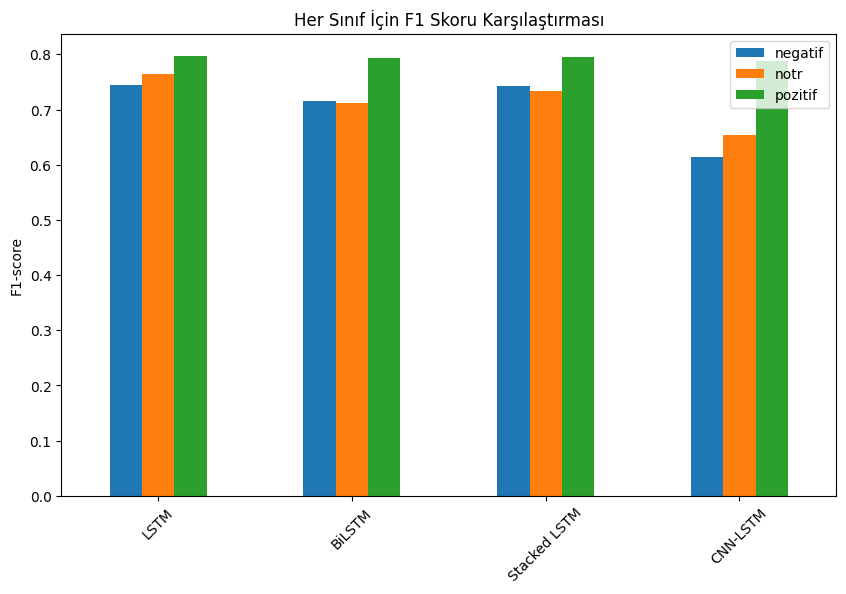

In [7]:
per_class = {}
for model, res in results.items():
    for cls in classes:
        if cls not in per_class:
            per_class[cls] = {}
        per_class[cls][model] = res["report"][cls]["f1-score"]

df_per_class = pd.DataFrame(per_class)
print(df_per_class)
df_per_class.plot(kind="bar", figsize=(10,6))
plt.title("Her Sınıf İçin F1 Skoru Karşılaştırması")
plt.ylabel("F1-score")
plt.xticks(rotation=45)
plt.show()